# LOAD LIBRARIES

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from scipy.stats import randint, uniform
from sklearn.model_selection import  PredefinedSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    infer_cv_block_size_from_gaps,
    create_block_splits,
    plot_cv_splits
)

# CONFIGURATION

In [11]:
START_DATE, END_DATE = '2023-11-08', '2024-08-21'
TARGET_FLUX = 'FCH4'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_ID = True
ADD_TRT = True

# LOAD DATA

In [12]:
data_main = fluxes = load_parquet(filepath=r"83.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 83.1.1_GapFillingDataset.parquet (0.248 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Using data from 2023-11-08 to 2024-08-21

Target column: FCH4_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,FCH4_L3.3_CUT_16_QCF,FCH4_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_84_QCF,FCH4_L3.3_CUT_16_QCF0,FCH4_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,NaN,2.367268,2.367268,1.568481,-0.798787,-3.231648,-3.231648,-3.231648,-3.231648,-3.231648,-3.231648,B,certain,1.0,...,0.055964,-1.641550,-0.086146,0.576043,0.0,0.0,2.185170,0.986663,29.0,22.0,30.0,22.0,0.300700,5.004348,1032
2023-11-08 00:45:00,NaN,NaN,2.238080,2.238080,1.591144,-0.646936,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,0.016644,-2.340741,0.001028,0.291943,0.0,0.0,2.179702,0.983564,29.0,22.0,30.0,22.0,0.300704,5.004376,1033
2023-11-08 01:15:00,NaN,NaN,2.207177,2.207177,1.586392,-0.620786,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,0.138010,-0.829823,0.242660,0.618842,0.0,0.0,2.174248,0.980476,29.0,22.0,30.0,22.0,0.300709,5.004405,1034
2023-11-08 01:45:00,NaN,NaN,2.186978,2.186978,1.587581,-0.599397,6.746138,6.746138,6.746138,NaN,NaN,NaN,B,certain,1.0,...,0.307449,-0.724752,0.260016,0.686303,0.0,0.0,2.168807,0.977400,29.0,22.0,30.0,22.0,0.300714,5.004433,1035
2023-11-08 02:15:00,NaN,NaN,2.179536,2.179536,1.584012,-0.595524,3.168362,3.168362,3.168362,3.168362,3.168362,3.168362,B,certain,1.0,...,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,30.0,22.0,0.300718,5.004462,1036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 21:45:00,NaN,NaN,4.338262,4.338262,4.553706,0.215444,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.707135,0.024579,-0.259299,-0.314632,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14851
2024-08-21 22:15:00,NaN,NaN,4.139963,4.139963,4.508099,0.368136,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.744187,0.026603,-0.248552,-0.346094,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14852
2024-08-21 22:45:00,NaN,NaN,4.134058,4.134058,4.478950,0.344892,-6.892062,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.720830,0.028865,-0.235925,-0.360680,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14853


# CLEAN DATA

In [13]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

data

Filtered parcel_certainty=='certain': 1356/1552 rows kept


,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,FCH4_L3.3_CUT_16_QCF,FCH4_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_84_QCF,FCH4_L3.3_CUT_16_QCF0,FCH4_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,NaN,2.367268,2.367268,1.568481,-0.798787,-3.231648,-3.231648,-3.231648,-3.231648,-3.231648,-3.231648,B,certain,1.0,...,0.055964,-1.641550,-0.086146,0.576043,0.0,0.0,2.185170,0.986663,29.0,22.0,30.0,22.0,0.300700,5.004348,1032
2023-11-08 02:15:00,NaN,NaN,2.179536,2.179536,1.584012,-0.595524,3.168362,3.168362,3.168362,3.168362,3.168362,3.168362,B,certain,1.0,...,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,30.0,22.0,0.300718,5.004462,1036
2023-11-08 02:45:00,NaN,NaN,1.652604,1.652604,1.580437,-0.072166,8.004995,8.004995,8.004995,8.004995,8.004995,8.004995,B,certain,1.0,...,0.245680,0.083496,0.088045,0.647077,0.0,0.0,2.157967,0.971280,29.0,22.0,30.0,22.0,0.300723,5.004490,1037
2023-11-08 03:15:00,NaN,NaN,1.651816,1.651816,1.570877,-0.080939,-3.270484,-3.270484,-3.270484,-3.270484,-3.270484,-3.270484,B,certain,1.0,...,0.059082,0.121729,0.069218,0.542432,0.0,0.0,2.152567,0.968238,29.0,22.0,30.0,22.0,0.300727,5.004519,1038
2023-11-08 05:15:00,NaN,NaN,1.513415,1.513415,1.557666,0.044251,-12.813660,-12.813660,-12.813660,-12.813660,-12.813660,-12.813660,B,certain,1.0,...,0.018764,0.876177,0.054961,0.979191,0.0,0.0,2.131102,0.956176,29.0,22.0,30.0,22.0,0.300746,5.004635,1042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-20 08:15:00,1.855749,1.855749,1.855749,1.855749,4.720574,2.864825,-19.752590,-19.752590,-19.752590,-19.752590,-19.752590,-19.752590,A,certain,0.0,...,-2.097743,-0.031954,0.008492,0.263486,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14776
2024-08-20 13:45:00,1.879419,1.879419,1.879419,1.879419,5.046906,3.167487,-6.165051,-6.165051,-6.165051,-6.165051,-6.165051,-6.165051,A,certain,0.0,...,-1.721083,-0.117190,-0.138414,0.034627,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14787
2024-08-21 00:15:00,4.887125,4.887125,4.887125,4.887125,4.970011,0.082886,45.188613,45.188613,45.188613,45.188613,45.188613,45.188613,B,certain,1.0,...,-1.507235,0.153967,-0.062227,-0.147486,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14808


# SELECT FEATURES

In [14]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'timesince_soil_preparation',
# 'n_decay_timed',
# 'timesince_fert',
# 'wfps_0.05_gfXG_lag9h',
# 'wfps_0.05_gfXG_roll3hmean',
# 'ts_0.3_gfXG_lag6h_roll9hmean',
# 'GPP_U50_f_reddyproc_roll3hsum'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

# Drop NAs and keep only selected features
train_mask = data[TARGET].notna() & data[selected_features].notna().all(axis=1)
df_train = data.loc[train_mask, selected_features + [TARGET]].copy()
print(f"\nTraining rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[selected_features]
y = df_train[TARGET].astype(float)

df_train


The treatment variable (trt) is included in the feature set

Training rows (complete-case): 1349/1356


,GPP_NT_CUT_50_gfXG_QCF0,trt,prec,timesince_prec,ts_0.15_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,NEE_L3.3_CUT_50_QCF_gfXGBoost_lag3h,RECO_NT_CUT_50_gfXG_QCF0_lag3h,RECO_NT_CUT_50_gfXG_QCF0_lag6h,RECO_NT_CUT_50_gfXG_QCF0_lag9h,ta_lag3h,ta_lag6h,ta_lag9h,...,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,n_decay_timed,timesince_fert,id,FCH4_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 10:15:00,8.884476,1.0,0.0,32.0,8.886193,55.111909,43.419158,21,1.459059,1.444111,1.543164,1.586392,1.966667,4.633333,5.833333,...,-2.354308,-1.516469,-0.394435,-0.853855,0.246965,-1.202668,1.031801,-0.107977,0.159447,-0.172413,-0.021793,29.0,22.0,1052,0.826520
2023-11-08 10:45:00,9.829791,1.0,0.0,33.0,9.382021,55.050766,43.408934,21,0.987352,1.449163,1.551635,1.587581,2.100000,4.866667,5.866667,...,-1.742575,-1.346654,-0.673985,-0.866037,0.275648,-0.747932,1.010233,-0.178831,0.145960,-0.260830,-0.040708,29.0,22.0,1053,9.740466
2023-11-08 14:15:00,8.049337,1.0,0.0,40.0,10.107077,55.354172,43.561690,22,-8.702924,1.698781,1.487957,1.557666,9.066667,3.133333,5.033333,...,0.304298,-1.426566,-0.803295,-0.560009,0.010804,0.246212,0.997085,0.075374,0.125579,0.096674,0.265060,29.0,23.0,1060,2.845860
2023-11-09 09:15:00,1.998003,1.0,0.0,78.0,7.162233,55.707137,41.127546,22,1.305089,1.378798,1.376202,1.391738,0.266667,0.200000,0.600000,...,-2.748989,-1.929940,-1.457546,-1.461164,-0.352656,-1.152182,-2.745121,-0.245556,0.221497,0.408271,-1.222534,29.0,23.0,1098,6.635354
2023-11-09 14:15:00,1.256899,1.0,0.0,88.0,9.357502,55.490160,42.656713,23,-6.231266,1.685196,1.428896,1.373604,8.666667,1.566667,0.133333,...,1.532258,-0.749575,-1.993988,-2.258015,0.566385,0.079600,-1.947521,-0.144982,-0.465814,0.135988,0.856629,29.0,24.0,1108,-14.870929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-20 08:15:00,2.864825,0.0,0.0,52.0,20.142223,47.381055,43.021562,15,4.246248,4.654718,4.680116,4.688412,15.466667,15.800000,15.903333,...,-1.584444,0.242223,-0.634447,-0.154816,-0.160069,-0.595461,-1.846004,-0.322147,-0.714479,-2.097743,-0.031954,0.0,30.0,14776,-19.752590
2024-08-20 13:45:00,3.167487,0.0,0.0,63.0,20.760370,46.977597,42.913925,16,1.169704,4.802366,4.696659,4.658547,17.500000,16.040000,15.516667,...,-0.039630,-0.536296,-0.459999,-0.231113,-0.298063,-0.486618,-1.591825,-0.458726,-0.740482,-1.721083,-0.117190,0.0,30.0,14787,-6.165051
2024-08-21 00:15:00,0.082886,1.0,0.0,84.0,21.465926,46.324699,42.904943,16,5.274635,4.882690,5.209183,5.195960,18.660000,23.460000,23.246667,...,1.054444,0.436666,0.731113,0.134520,-0.742244,-2.381714,-2.675015,-0.318737,-0.733296,-1.507235,0.153967,0.0,30.0,14808,45.188613


# IMBALANCE HANDLING

## UNDER SAMPLING

In [15]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

In [16]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")

Log transform not applied.


# CROSS-VAL SPLITS


Using block size of 4 time steps for CV splits.

Requested split=0.10; n_folds=10; achieved test fractions ~ 0.098–0.101


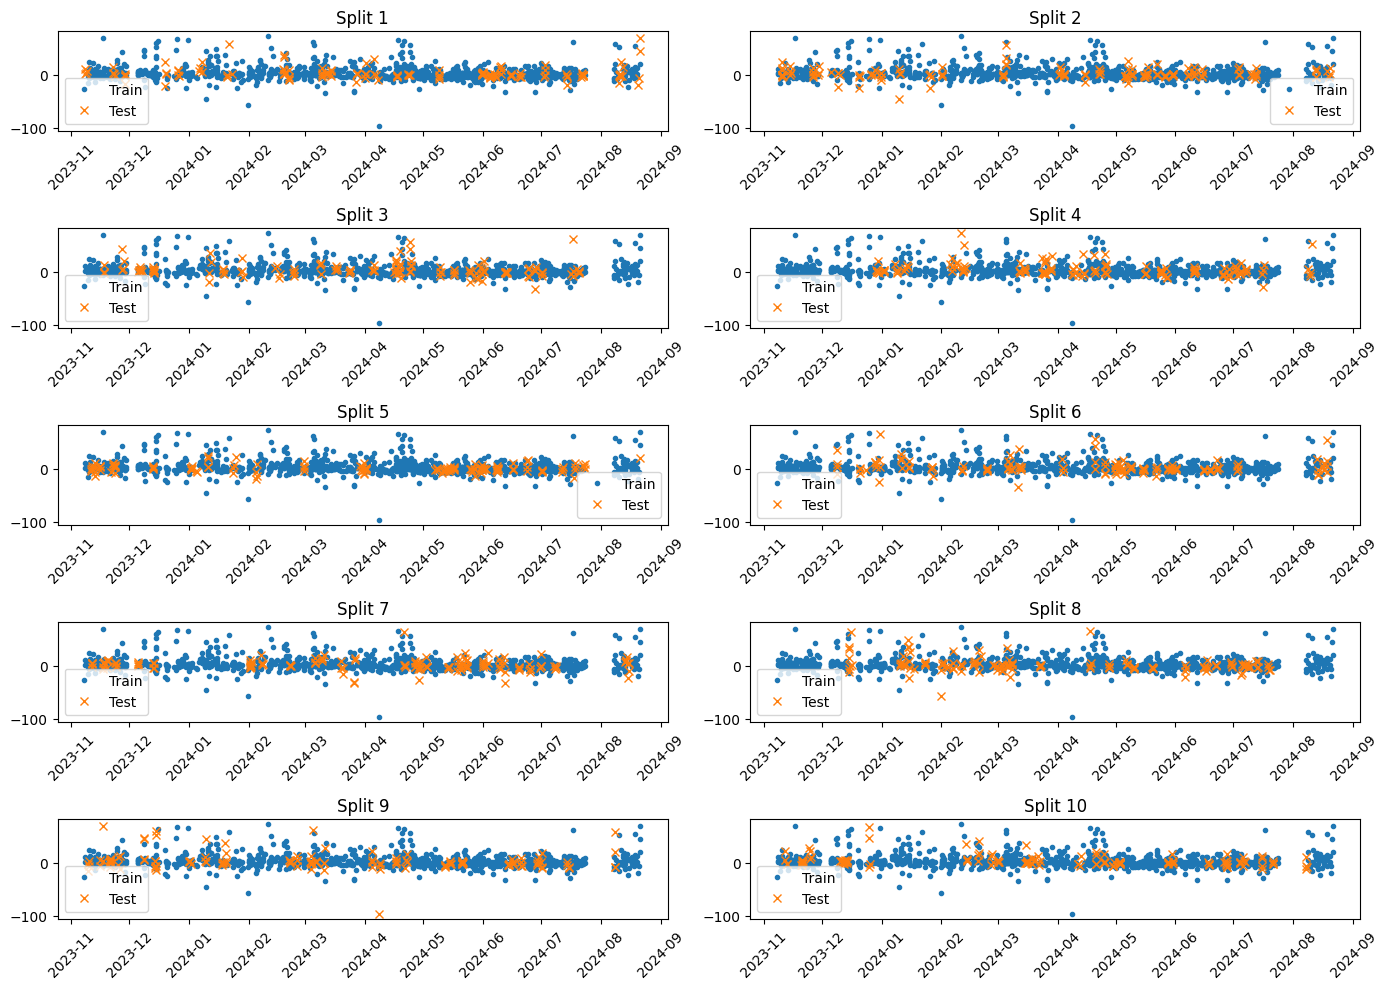

In [17]:
# Time-block cross-validation splits
# Block size is inferred from gaps in the target variable
block_size = infer_cv_block_size_from_gaps(data_main[TARGET], quantile=0.9, fallback=6)
print(f"\nUsing block size of {block_size} time steps for CV splits.\n")
split_frac = 1.0 / float(N_FOLDS)
splits = create_block_splits(
    X,
    split=split_frac,
    block_size=block_size,
    random_state=42,
    shuffle_blocks=True,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# HYPERPARAMETER TUNING

In [18]:
# Convert custom CV splits to PredefinedSplit for Scikit-Learn
test_fold = np.full(len(X), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
ps = PredefinedSplit(test_fold)

# DEFINE RANGES
if MODEL_TYPE == 'XGBoost':
    # XGBoost: Use continuous distributions for fine-tuning
    PARAM_DIST = {
        'n_estimators': randint(100, 1000),      # Any integer 100-1000
        'max_depth': randint(3, 15),             # Any integer 3-15
        'learning_rate': uniform(0.005, 0.1),    # Any float 0.005-0.105
        'subsample': uniform(0.6, 0.4),          # 0.6 to 1.0
        'colsample_bytree': uniform(0.6, 0.4),   # 0.6 to 1.0
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 0.5)
    }
    model = XGBRegressor(n_jobs=-1, random_state=42)

elif MODEL_TYPE == 'RandomForest':
    # RF: Integers for counts/depths
    PARAM_DIST = {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 1.0]
    }
    model = RandomForestRegressor(n_jobs=-1, random_state=42)

# RUN RANDOM SEARCH
print(f"Starting optimization for {MODEL_TYPE}...")

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=PARAM_DIST,
    n_iter=100,       # random tries
    cv=ps,           # Uses your exact time-blocks
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
search.fit(X, y)

# RESULTS
print(f"Best RMSE: {-search.best_score_:.4f}")
print("Best Params:", search.best_params_)

Starting optimization for XGBoost...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best RMSE: 11.7135
Best Params: {'colsample_bytree': np.float64(0.8887995089067299), 'gamma': np.float64(0.4692763545078751), 'learning_rate': np.float64(0.005077876584101433), 'max_depth': 14, 'min_child_weight': 5, 'n_estimators': 260, 'subsample': np.float64(0.7216968971838151)}


# EXPORT 

In [19]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(search.best_params_, f)

# **End of notebook**

In [20]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-01-28 13:07:08
